**Tabla de contenido**

- [Lectura de datos](#Lectura-de-datos)
- [Preprocesamiento](#Preprocesamiento)
- [Modelado](#Modelado)

# Lectura de datos

In [1]:
import pandas as pd
import numpy as np
import os
file_path = lambda file: os.path.join(os.getcwd(),'data',file)
df_vid= pd.read_csv(file_path('USvideos.csv'))

# Preprocesamiento

In [3]:
df = df_vid[['views','likes','dislikes','comment_count']]
df.head()

,views,likes,dislikes,comment_count
0,748374,57527,2966,15954
1,2418783,97185,6146,12703
2,3191434,146033,5339,8181
3,343168,10172,666,2146
4,2095731,132235,1989,17518


# Modelado

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
modelo_regresion_validacion = LinearRegression()
independientes = df.drop(columns=['likes'],axis=1)
objetivo = df['likes']

modelo = LinearRegression()

In [12]:
# estableciendo funcion que va a realizar la validacion cruzada
# scoring= raiz cuadrada del error cuadratico medio rmse (neg_root_mean_squared_error)
#cv = cuantas validaciones quiero realizar
cross_val_score(modelo,
                independientes,
                objetivo,
                scoring = "neg_root_mean_squared_error",
                cv=10)
# calculando el promedio de los errores y almacenandolos en una lista 
rmse_validacion =[-cross_val_score(modelo_regresion_validacion,
                independientes,
                objetivo,
                scoring = "neg_root_mean_squared_error",
                cv=x).mean() for x in range(10,150)]

evaluacion_cruzada = {"particiones":list(range(10,150)),
                      "rmse_validacion":rmse_validacion}
evaluacion_cruzada = pd.DataFrame(evaluacion_cruzada)
evaluacion_cruzada.head()

,particiones,rmse_validacion
0,10,79597.073650
1,11,79043.037208
2,12,78812.337861
3,13,79354.096612
4,14,79185.452034


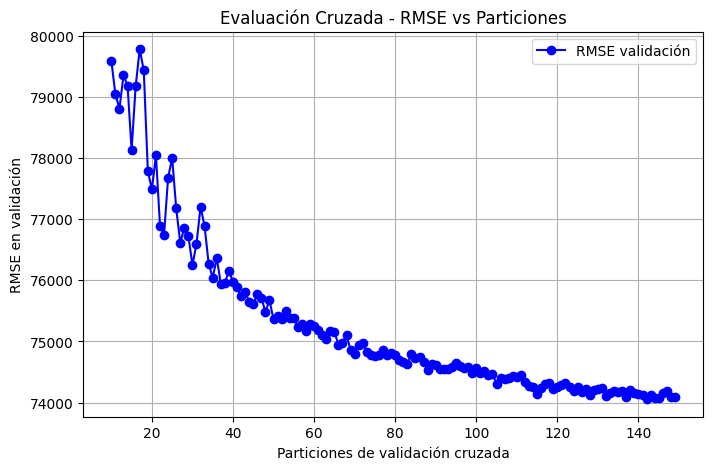

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(
    evaluacion_cruzada["particiones"],
    evaluacion_cruzada["rmse_validacion"],
    marker="o", linestyle="-", color="blue", label="RMSE validación"
)

plt.xlabel("Particiones de validación cruzada")
plt.ylabel("RMSE en validación")
plt.title("Evaluación Cruzada - RMSE vs Particiones")
plt.legend()
plt.grid(True)
plt.show()